<a href="https://colab.research.google.com/github/AHMEDVALL70/ahmed-vall-cv/blob/main/Sentiment_Analysis_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Project 04: Sentiment Analysis of Customer Reviews

**Author:** Ahmed Vall Jemal Dine Sidina | AHMEDVALL70

**Context:** Inspired by diplomatic reporting needs — extracting structured insights from unstructured text mirrors the analytical work required in consular affairs.

**Goal:** Perform NLP-based sentiment analysis on customer reviews to classify opinions as positive or negative, with interactive visualization.

**Libraries:** TextBlob · Matplotlib · Pandas

**Use Cases:** Customer feedback analysis · Brand monitoring · Opinion mining

📊 Sentiment Analysis Results:
-----------------------------------------------------------------
  Positive 😊 | +0.75 | I love this product, it works perfe
  Negative 😡 | -0.70 | The service was terrible and very s
  Positive 😊 | +0.75 | It is okay, not the best but works.
  Negative 😡 | -1.00 | This is the worst experience ever.
  Positive 😊 | +0.30 | Fantastic quality, highly recommend
  Positive 😊 | +0.90 | Great work, I am happy with the res
  Negative 😡 | -1.00 | Absolutely horrible, never buying a
  Positive 😊 | +0.36 | Pretty good overall, satisfied with
  Negative 😡 | -0.78 | Very disappointing product quality.
  Positive 😊 | +0.38 | Outstanding service and fast delive
-----------------------------------------------------------------
✅ Positive: 6 | ❌ Negative: 4 | 😐 Neutral: 0


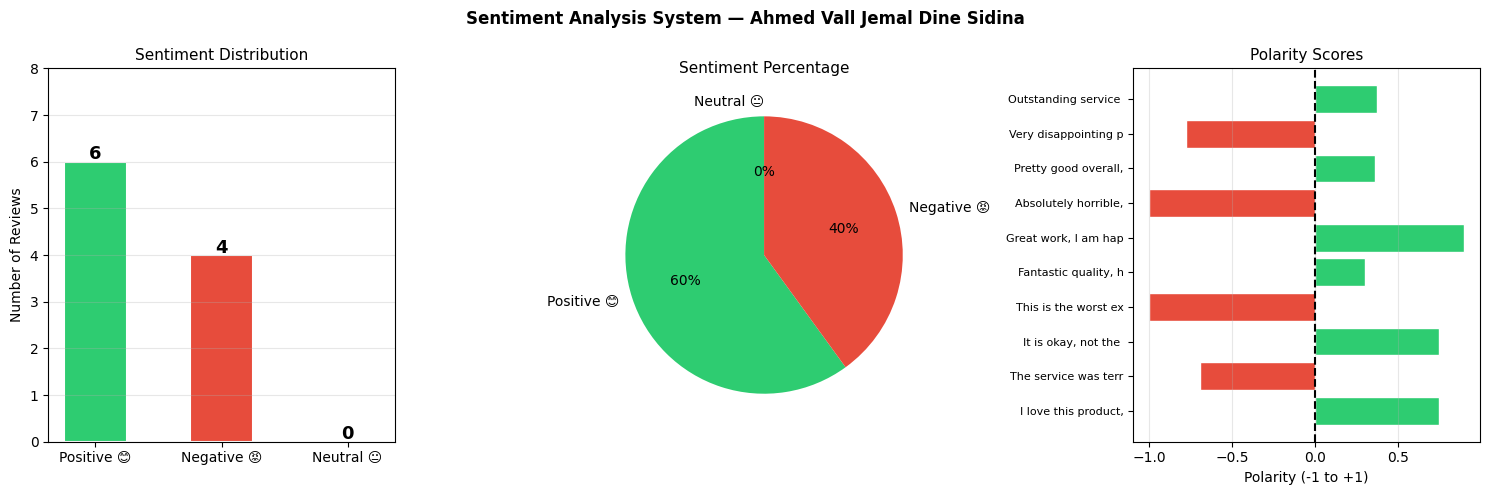

✅ تم حفظ الرسم البياني!


In [1]:
!pip install textblob -q
import matplotlib.pyplot as plt
from textblob import TextBlob

# ── البيانات ──
reviews = [
    "I love this product, it works perfectly!",
    "The service was terrible and very slow.",
    "It is okay, not the best but works.",
    "This is the worst experience ever.",
    "Fantastic quality, highly recommended!",
    "Great work, I am happy with the results!",
    "Absolutely horrible, never buying again.",
    "Pretty good overall, satisfied with purchase.",
    "Very disappointing product quality.",
    "Outstanding service and fast delivery!"
]

# ── تحليل المشاعر ──
results = []
positive = negative = neutral = 0
scores = []

for review in reviews:
    polarity = TextBlob(review).sentiment.polarity
    scores.append(polarity)
    if polarity > 0:
        sentiment = 'Positive 😊'
        positive += 1
    elif polarity < 0:
        sentiment = 'Negative 😡'
        negative += 1
    else:
        sentiment = 'Neutral 😐'
        neutral += 1
    results.append((review[:35], round(polarity, 2), sentiment))

print("📊 Sentiment Analysis Results:")
print("-" * 65)
for review, score, sent in results:
    print(f"  {sent} | {score:+.2f} | {review}")
print("-" * 65)
print(f"✅ Positive: {positive} | ❌ Negative: {negative} | 😐 Neutral: {neutral}")

# ── الرسم البياني ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Sentiment Analysis System — Ahmed Vall Jemal Dine Sidina',
             fontsize=12, fontweight='bold')

# 1️⃣ Bar Chart
labels = ['Positive 😊', 'Negative 😡', 'Neutral 😐']
counts = [positive, negative, neutral]
colors = ['#2ecc71', '#e74c3c', '#95a5a6']
bars = axes[0].bar(labels, counts, color=colors,
                    edgecolor='white', linewidth=1.5, width=0.5)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 str(count), ha='center',
                 fontweight='bold', fontsize=13)
axes[0].set_title('Sentiment Distribution', fontsize=11)
axes[0].set_ylabel('Number of Reviews')
axes[0].set_ylim(0, max(counts) + 2)
axes[0].grid(True, alpha=0.3, axis='y')

# 2️⃣ Pie Chart
axes[1].pie(counts, labels=labels, colors=colors,
            autopct='%1.0f%%', startangle=90,
            textprops={'fontsize': 10})
axes[1].set_title('Sentiment Percentage', fontsize=11)

# 3️⃣ Polarity Scores
bar_colors = ['#2ecc71' if s > 0 else '#e74c3c' if s < 0 else '#95a5a6'
              for s in scores]
axes[2].barh(range(len(scores)), scores, color=bar_colors,
              edgecolor='white', linewidth=1)
axes[2].axvline(x=0, color='black', linewidth=1.5, linestyle='--')
axes[2].set_yticks(range(len(reviews)))
axes[2].set_yticklabels([r[:20] for r in reviews], fontsize=8)
axes[2].set_title('Polarity Scores', fontsize=11)
axes[2].set_xlabel('Polarity (-1 to +1)')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('sentiment_analysis_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ تم حفظ الرسم البياني!")